##**AI-Powered Financial Fraud Detection & Risk Intelligence System**

##**Business Problem**

Banks and digital payment platforms process millions of financial transactions every day. Among these transactions, fraudulent activities cause significant financial losses, damage customer trust, and increase operational costs.

Traditional rule-based fraud detection systems often fail to identify new fraud patterns and may generate a large number of false alarms.

The objective of this project is to Develop an explainable machine learning system capable of detecting fraudulent financial transactions while balancing fraud detection performance with operational efficiency.

##**IMPORT LIBRARIES**

This section imports all required libraries for data manipulation, visualization, machine learning, model evaluation, and explainability.

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
%matplotlib inline

In [2]:
# Dataset Loading
#The fraud transaction dataset is loaded into a pandas DataFrame for further preprocessing and analysis.
df = pd.read_csv("/content/Project E$  (4).csv")

In [3]:
df.sample(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
301739,15,CASH_OUT,246968.59,C1214501264,8593.00,0.00,C970690658,0.00,246968.59,0,0
755132,38,TRANSFER,183585.39,C1379608123,0.00,0.00,C2030714194,185600.51,369185.90,0,0
300253,15,PAYMENT,22397.46,C319528479,0.00,0.00,M2049180813,0.00,0.00,0,0
582194,33,CASH_IN,123917.93,C1174484288,2785427.65,2909345.58,C97406924,568289.45,582180.34,0,0
915834,43,TRANSFER,330350.77,C1173387379,11196.34,0.00,C1631210013,1406893.62,1737244.40,0,0


##**Exploratory Data Analysis (EDA)**

Objective

• Understand the dataset

• Identify missing values

• Detect anomalies

• Analyze class imbalance

• Discover fraud patterns

In [4]:
df.shape

(1048575, 11)

**Observation**

The dataset contains 1,048,575 transactions and 11 features.

The large dataset size makes it suitable for training robust machine learning models.

In [5]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 88.0+ MB


**Observation**

• No missing values found.

• Numerical and categorical features are present.

• Dataset is clean from null values.

In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1048575.0
mean,2.696617e+01,1.586670e+05,8.740095e+05,8.938089e+05,9.781600e+05,1.114198e+06,1.089097e-03,0.0
std,1.562325e+01,2.649409e+05,2.971751e+06,3.008271e+06,2.296780e+06,2.416593e+06,3.298351e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.500000e+01,1.214907e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,2.000000e+01,7.634333e+04,1.600200e+04,0.000000e+00,1.263772e+05,2.182604e+05,0.000000e+00,0.0
75%,3.900000e+01,2.137619e+05,1.366420e+05,1.746000e+05,9.159235e+05,1.149808e+06,0.000000e+00,0.0
max,9.500000e+01,1.000000e+07,3.890000e+07,3.890000e+07,4.210000e+07,4.220000e+07,1.000000e+00,0.0


**Observation**

Large variation in transaction amounts and account balances indicates presence of outliers.
Fraud cases are extremely rare, confirming a highly imbalanced dataset.
Metrics like Precision, Recall, and F1-score will be more meaningful than Accuracy.

In [8]:
df.describe(include="object")

,type,nameOrig,nameDest
count,1048575,1048575,1048575
unique,5,1048317,449635
top,CASH_OUT,C443816828,C985934102
freq,373641,2,98


**Observation**

The dataset contains only one categorical feature (type).

Transaction type will require encoding before model training.

In [9]:
df.duplicated().sum()

np.int64(0)

**Observation:**

No duplicate records were found.

Duplicate removal is not required.

##**Class Distribution (Target Variable)**

In [10]:
df["isFraud"].value_counts()

,count
isFraud,
0,1047433
1,1142


In [11]:
df["isFraud"].value_counts(normalize=True)*100

,proportion
isFraud,
0,99.89109
1,0.10891


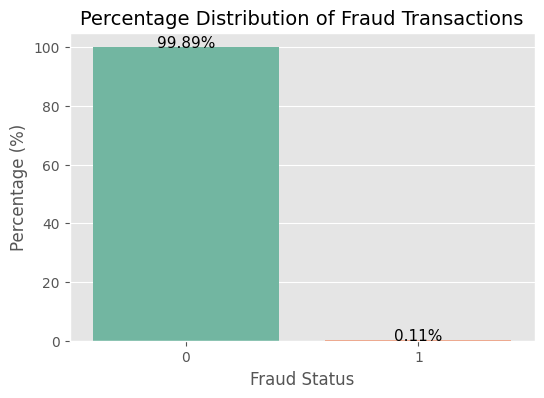

In [12]:
fraud_percent = df["isFraud"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=fraud_percent.index.astype(str),
    y=fraud_percent.values,
    palette="Set2"
)

plt.title("Percentage Distribution of Fraud Transactions", fontsize=14)
plt.xlabel("Fraud Status")
plt.ylabel("Percentage (%)")

for i, v in enumerate(fraud_percent.values):
    plt.text(i, v + 0.05, f"{v:.2f}%", ha="center", fontsize=11)

plt.show()

## Initial Observations

- The dataset contains over 1 million financial transactions.
- No missing values were found in the dataset.
- No duplicate records were detected.
- The target variable (`isFraud`) is highly imbalanced.
- Around **99.89%** of transactions are legitimate, while only **0.11%** are fraudulent.
- This class imbalance must be considered during model development to avoid biased predictions.

##**Univariate Analysis**

**Transaction Type Distribution**

In [13]:
df["type"].value_counts()

,count
type,
CASH_OUT,373641
PAYMENT,353873
CASH_IN,227130
TRANSFER,86753
DEBIT,7178


In [14]:
round(df["type"].value_counts(normalize=True) * 100, 2)

,proportion
type,
CASH_OUT,35.63
PAYMENT,33.75
CASH_IN,21.66
TRANSFER,8.27
DEBIT,0.68


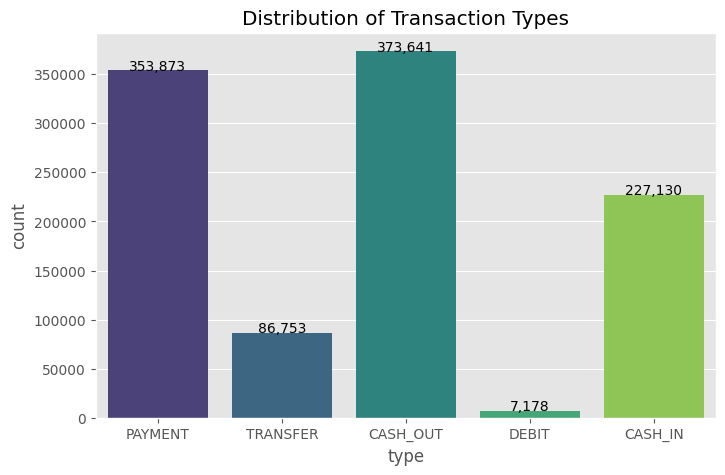

In [15]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x="type", palette="viridis")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center")

plt.title("Distribution of Transaction Types")
plt.show()

### Observation

- CASH_OUT is the most common transaction type with **373,641** transactions.
- PAYMENT is the second most frequent transaction type with **353,873** transactions.
- CASH_IN also represents a significant portion of the transactions.
- TRANSFER transactions are comparatively lower (**86,753**).
- DEBIT transactions are the least frequent (**7,178**).
- The distribution of transaction types is not uniform across the dataset.
-CASH_OUT and TRANSFER transactions require special attention because fraudulent activities are predominantly associated with these transaction types.

##**Transaction Type vs Fraud**

In [16]:
# Fraud count in each transaction type
pd.crosstab(df["type"], df["isFraud"])

isFraud,0,1
type,,
CASH_IN,227130,0
CASH_OUT,373063,578
DEBIT,7178,0
PAYMENT,353873,0
TRANSFER,86189,564


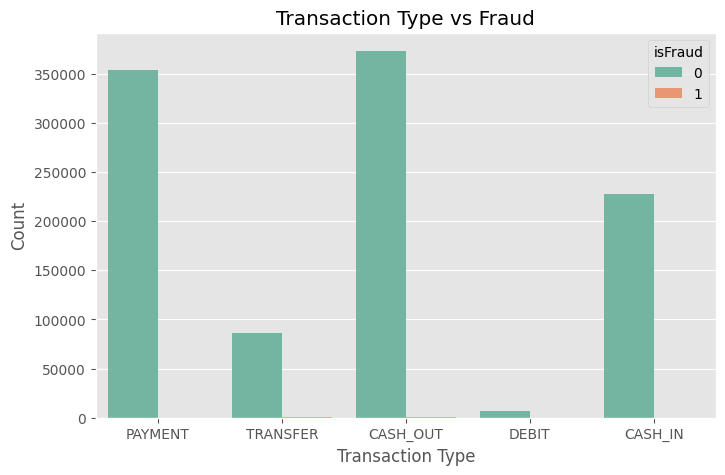

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="type",hue="isFraud",palette="Set2")
plt.title("Transaction Type vs Fraud")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

**Final Observation**

• Fraudulent transactions are concentrated in TRANSFER and CASH_OUT transaction types.

• PAYMENT, CASH_IN, and DEBIT transactions show almost no fraudulent activity.

• Transaction type appears to be a strong predictor for fraud detection.

##**Transaction Amount Analysis**

In [18]:
df["amount"].describe()

,amount
count,1.048575e+06
mean,1.586670e+05
std,2.649409e+05
min,1.000000e-01
25%,1.214907e+04
50%,7.634333e+04
75%,2.137619e+05
max,1.000000e+07


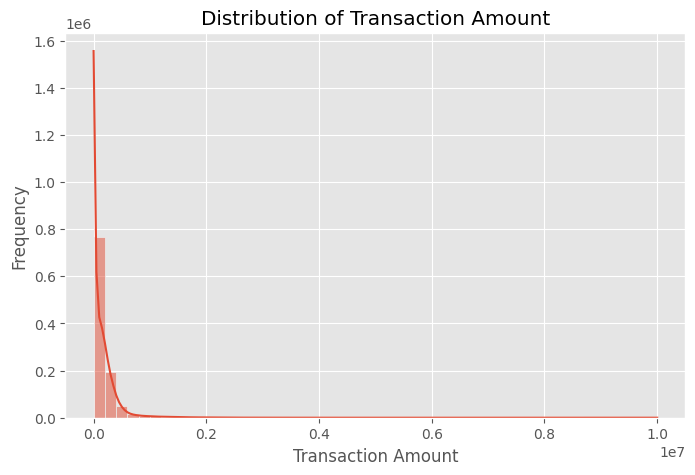

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["amount"], bins=50, kde=True)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

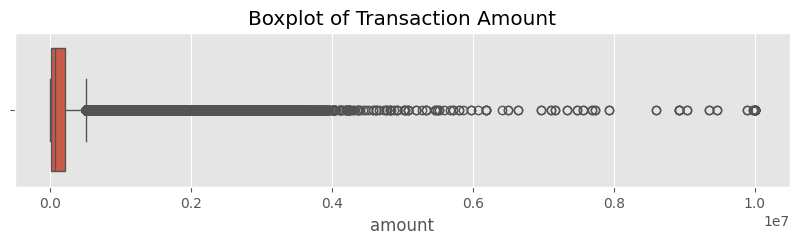

In [20]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df["amount"])

plt.title("Boxplot of Transaction Amount")

plt.show()

In [21]:
df["amount"].skew()

np.float64(6.374165698763262)

### Observation

- The transaction amount is highly right-skewed.
- Most transactions involve relatively small amounts.
- A few transactions contain extremely large values, creating a long right tail.
- The boxplot reveals a large number of potential outliers.
- The skewness value (6.37) confirms that the feature is highly positively skewed.

### Decision

✅ Missing Values → No

✅ Highly Skewed → Yes

✅ Outliers Present → Yes

🟡 Remove Outliers → Decision Pending

🟡 Scaling Required → Yes

##**Amount vs isFraud**

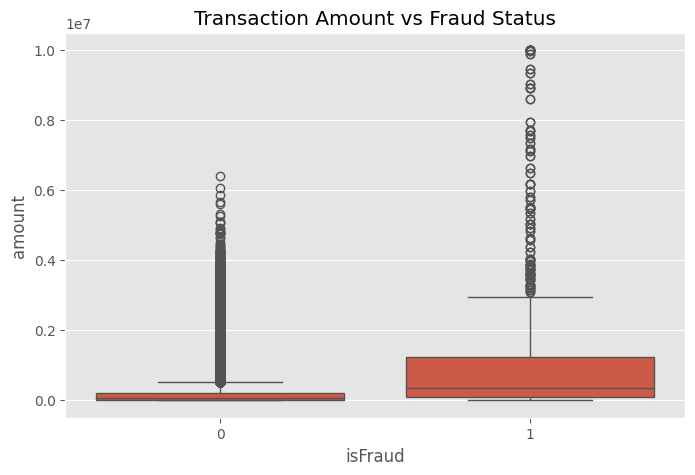

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="amount"
)

plt.title("Transaction Amount vs Fraud Status")

plt.show()

**Observation**

• Fraudulent transactions generally involve higher transaction amounts.

• Some overlap exists between genuine and fraudulent transactions.

• Transaction amount alone is insufficient for accurate fraud detection.

##**Transaction Step Analysis**

In [23]:
df["step"].describe()

,step
count,1.048575e+06
mean,2.696617e+01
std,1.562325e+01
min,1.000000e+00
25%,1.500000e+01
50%,2.000000e+01
75%,3.900000e+01
max,9.500000e+01


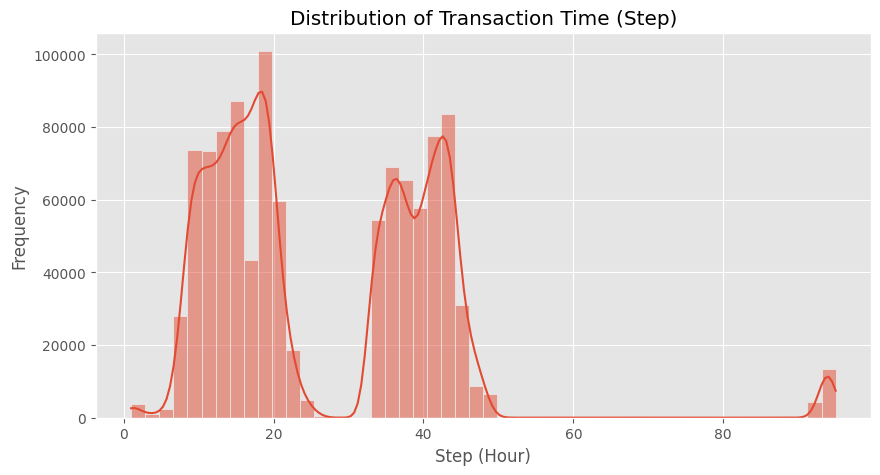

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(df["step"], bins=50, kde=True)

plt.title("Distribution of Transaction Time (Step)")
plt.xlabel("Step (Hour)")
plt.ylabel("Frequency")

plt.show()

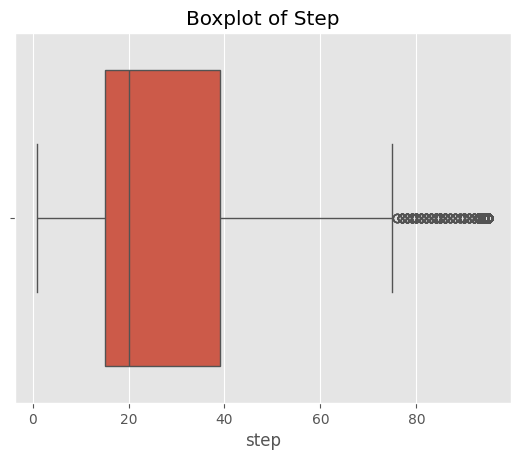

In [25]:
sns.boxplot(x=df["step"])

plt.title("Boxplot of Step")

plt.show()

In [26]:
df["step"].skew()

np.float64(1.294454639122211)

### Observation

- The `step` feature ranges from **1 to 95 hours**.
- The average transaction time is **26.97 hours**, while the median is **20 hours**.
- The distribution is positively skewed (Skewness = 1.294).
- The histogram shows multiple peaks, indicating that transactions are concentrated during specific time periods rather than being uniformly distributed.
- A few transactions occur during later hours, which appear as outliers in the boxplot.

### Decision

✅ Missing Values → No

✅ Highly Skewed → Yes

❌ Remove Outliers → No (Valid Time Values)

🟡 Scaling → Not Required for Tree Models

✅ Useful Feature → Yes

##**BIVARIATE ANALYSIS**

**Sender Balance Before Transaction vs Fraud Status**

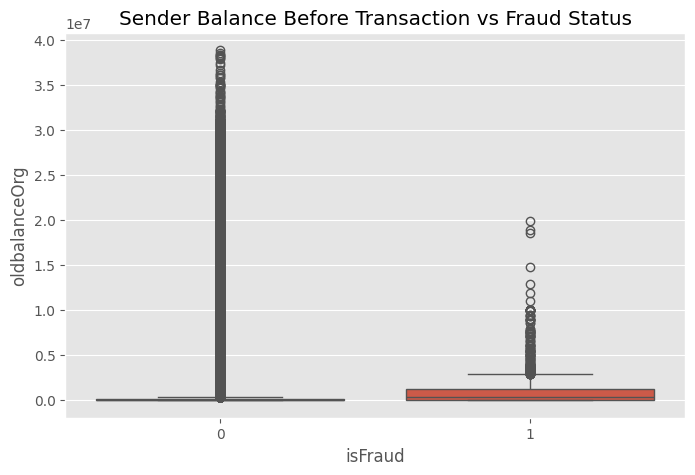

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="oldbalanceOrg"
)

plt.title("Sender Balance Before Transaction vs Fraud Status")

plt.show()

In [28]:
df.groupby("isFraud")["oldbalanceOrg"].agg(["mean","median","min","max"])

,mean,median,min,max
isFraud,,,,
0,8.736338e+05,15937.000,0.0,38900000.0
1,1.218636e+06,348705.145,0.0,19900000.0


### Observation

- Fraudulent transactions have a significantly higher median sender balance than genuine transactions.
- The median sender balance for fraud transactions is ₹348,705 compared to ₹15,937 for genuine transactions.
- The average sender balance is also higher in fraudulent transactions.
- This suggests that fraudsters often target or operate from accounts with higher available balances.

In [29]:
balance_features = ["oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]

df[balance_features].describe().T

,count,mean,std,min,25%,50%,75%,max
oldbalanceOrg,1048575.0,8.740095e+05,2.971751e+06,0.0,0.0,16002.00,136642.020,38900000.0
newbalanceOrig,1048575.0,8.938089e+05,3.008271e+06,0.0,0.0,0.00,174599.990,38900000.0
oldbalanceDest,1048575.0,9.781600e+05,2.296780e+06,0.0,0.0,126377.21,915923.475,42100000.0
newbalanceDest,1048575.0,1.114198e+06,2.416593e+06,0.0,0.0,218260.36,1149807.510,42200000.0


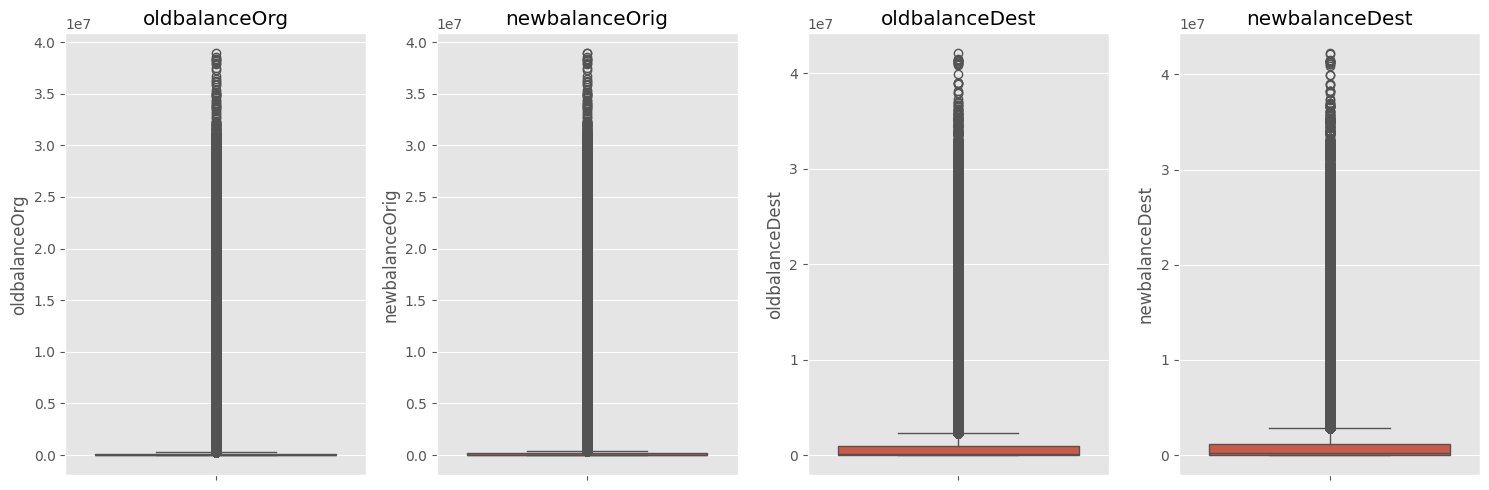

In [30]:
plt.figure(figsize=(15,5))

for i,col in enumerate(balance_features,1):
    plt.subplot(1,4,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [31]:
df[balance_features].skew().sort_values(ascending=False)

,0
oldbalanceDest,5.373195
oldbalanceOrg,5.124286
newbalanceOrig,5.060456
newbalanceDest,5.012456


In [32]:
df.groupby("isFraud")[balance_features].agg(["mean","median"])

oldbalanceOrg             newbalanceOrig        oldbalanceDest  \
                 mean      median           mean median           mean   
isFraud                                                                  
0        8.736338e+05   15937.000  894746.395080    0.0  978732.769117   
1        1.218636e+06  348705.145   33944.321208    0.0  452866.124527   

                   newbalanceDest              
            median           mean      median  
isFraud                                        
0        126863.76   1.114237e+06  218484.080  
1             0.00   1.077940e+06   13798.765

### Observation

• All balance-related features contain a large number of outliers.

• All balance features are highly positively skewed.

• Fraudulent transactions generally have a higher sender balance before the transaction (oldbalanceOrg).

• Fraudulent transactions often leave the sender account with a very low or zero balance after the transaction (newbalanceOrig).

• Receiver balances also show noticeable differences between fraudulent and genuine transactions.

• Balance-related features appear to be strong predictors for fraud detection.

### Decision

✅ Missing Values → No

✅ Outliers → Present

✅ Skewed Distribution → Yes

❌ Remove Outliers → No

🟡 Scaling → Later

✅ Feature Engineering Required → Yes

##**Correlation Check**

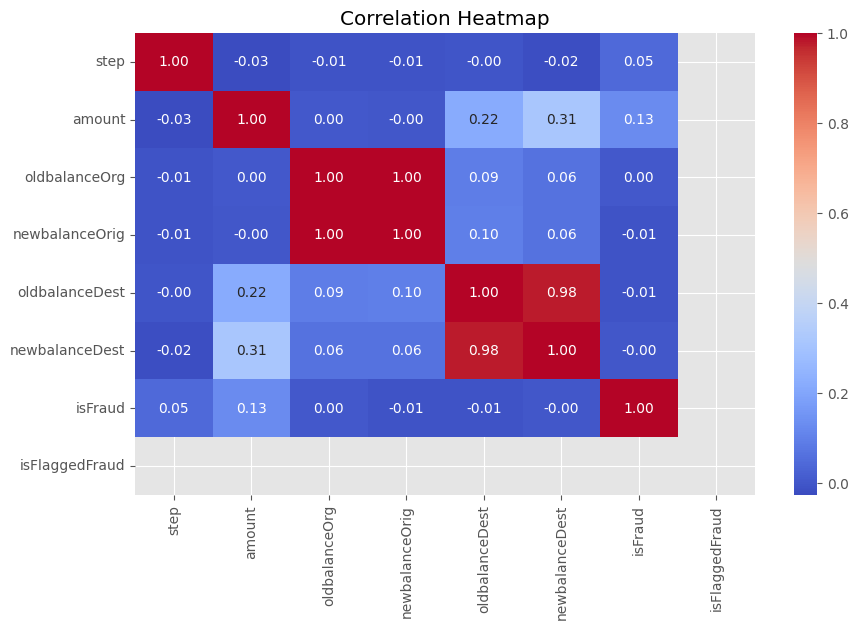

In [33]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

### Correlation Analysis

- Sender balance before and after the transaction are highly correlated.
- Receiver balance before and after the transaction also show a strong positive correlation.
- Transaction amount has a moderate positive correlation with the receiver's new balance.
- The target variable (`isFraud`) has low linear correlation with individual features.
- Fraud detection is likely to depend on the combined interaction of multiple features rather than a single feature.

##**EDA Summary**

- Dataset contains more than 1 million financial transactions.
- No missing values or duplicate records were found.
- The target variable is highly imbalanced.
- Fraud occurs primarily in CASH_OUT and TRANSFER transactions.
- Transaction amount is highly right-skewed and contains many outliers.
- Balance-related features are highly skewed and contain significant outliers.
- Sender and receiver balance features exhibit strong correlations.
- Individual features show weak linear correlation with the target, indicating that fraud detection depends on complex feature interactions.

##**DATA PREPROCCESING**

**Feature Engineering**

In [34]:
# FEATURE 1
df["sender_balance_diff"] = df["oldbalanceOrg"] - df["newbalanceOrig"]

In [35]:
# FEATURE 2
df["expected_sender_balance"] = df["oldbalanceOrg"] - df["amount"]

In [36]:
# FEATURE 3
df["sender_balance_error"] = (df["expected_sender_balance"]- df["newbalanceOrig"])

In [37]:
# FEATURE 4
df["receiver_balance_diff"] = (df["newbalanceDest"]- df["oldbalanceDest"])

In [38]:
df[["sender_balance_diff","expected_sender_balance","sender_balance_error","receiver_balance_diff"]].sample(10)

,sender_balance_diff,expected_sender_balance,sender_balance_error,receiver_balance_diff
79304,19188.85,-21361.82,-21361.82,40550.67
667468,164581.00,-199914.82,-199914.82,364495.81
476030,1776.00,-15989.20,-15989.20,396316.00
87052,70944.00,-301359.11,-301359.11,372303.11
790391,13616.00,-153690.45,-153690.45,167306.45
49417,12681.95,355052.86,0.00,0.00
878294,0.00,-81098.34,-81098.34,-26959.16
86961,66442.00,-121130.91,-121130.91,187572.91
251437,12962.37,-10083.52,-10083.52,0.00
593229,-100000.00,11533111.93,-166888.07,-66888.07


In [39]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'sender_balance_diff', 'expected_sender_balance',
       'sender_balance_error', 'receiver_balance_diff'],
      dtype='object')

To establish a fair baseline model, the engineered features are temporarily removed. They will be reintroduced later to evaluate the impact of feature engineering on model performance.

In [40]:
df.drop(columns=[
    "sender_balance_diff",
    "expected_sender_balance",
    "sender_balance_error",
    "receiver_balance_diff"
], inplace=True)

##**Base Line Model To Before Feature Engineering to Make Feature Engineering Efficient**

In [41]:
#drop useless columns
df.drop(columns=["nameOrig","nameDest","isFlaggedFraud"], inplace=True)

In [42]:
df["type"].value_counts()

,count
type,
CASH_OUT,373641
PAYMENT,353873
CASH_IN,227130
TRANSFER,86753
DEBIT,7178


**One Hot Encoding**

In [43]:
df = pd.get_dummies(df, columns=["type"], drop_first=True, dtype=int)

In [44]:
df.columns

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'type_CASH_OUT', 'type_DEBIT',
       'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')

**Train/Test/Split**

In [45]:
X = df.drop("isFraud", axis=1)
y = df["isFraud"]

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

**SCALING**

Standardization is applied for algorithms such as Logistic Regression.

Tree-based models (Decision Tree, Random Forest, XGBoost) generally do not require feature scaling.



In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##**Baseline Model (Before Feature Engineering)**

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier

models={
    "Logistic Regression":LogisticRegression(random_state=42),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(random_state=42),
    "Gradient Boosting":GradientBoostingClassifier(random_state=42),
    "XGBoost":XGBClassifier(random_state=42,eval_metric="logloss")
}

**Objective**

Evaluate multiple baseline algorithms to identify the most suitable model before applying feature engineering and optimization.

In [49]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

results=[]

for name,model in models.items():

    if name=="Logistic Regression":
        model.fit(X_train_scaled,y_train)
        y_pred=model.predict(X_test_scaled)
        y_prob=model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train,y_train)
        y_pred=model.predict(X_test)
        y_prob=model.predict_proba(X_test)[:,1]

    results.append([
        name,
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred),
        recall_score(y_test,y_pred),
        f1_score(y_test,y_pred),
        roc_auc_score(y_test,y_prob)
    ])

results=pd.DataFrame(results,columns=["Model","Accuracy","Precision","Recall","F1 Score","ROC AUC"])
results.sort_values("F1 Score",ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,XGBoost,0.999719,0.951872,0.780702,0.857831,0.983608
2,Random Forest,0.999723,0.988506,0.754386,0.855721,0.971035
1,Decision Tree,0.999542,0.808411,0.758772,0.782805,0.879288
0,Logistic Regression,0.999080,1.000000,0.153509,0.266160,0.926112
3,Gradient Boosting,0.997783,0.188976,0.315789,0.236453,0.551188


### Baseline Model Comparison

- XGBoost achieved the highest Recall (78.07%), F1 Score (85.78%), and ROC-AUC (98.36%).
- Random Forest delivered performance close to XGBoost and serves as a strong alternative.
- Decision Tree produced reasonable results but was less stable than ensemble methods.
- Logistic Regression failed to capture the minority class due to severe class imbalance.
- Gradient Boosting underperformed with default hyperparameters, indicating that further tuning would be required.

##**Model Selection**

**Based on the baseline comparison, XGBoost achieved the best balance between Recall, F1-score, and ROC-AUC. Therefore, it was selected for further optimization.**

In [50]:
from xgboost import XGBClassifier
xgb=XGBClassifier(random_state=42,eval_metric="logloss")
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

##**Confusion Matrix**

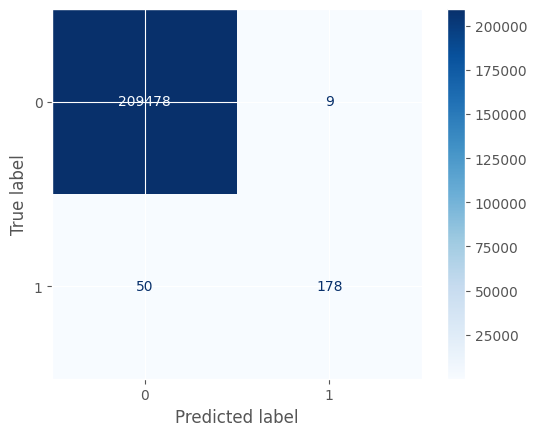

In [51]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.show()

### Observation

• Only a small number of fraudulent transactions were missed.

• False positives remain very low.

• The model demonstrates strong fraud detection capability.

##**Classification report**

In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209487
           1       0.95      0.78      0.86       228

    accuracy                           1.00    209715
   macro avg       0.98      0.89      0.93    209715
weighted avg       1.00      1.00      1.00    209715



### Observation

• Precision and Recall indicate effective detection of fraudulent transactions.

• High F1-score reflects a good balance between Precision and Recall.

• ROC-AUC confirms strong discrimination between fraud and legitimate transactions.

##**Optimization Phase**

## Objective
Improve the baseline XGBoost model by tuning key hyperparameters to achieve better fraud detection performance while maintaining a balance between Precision, Recall, and F1-score.

**Hyperparameter Optimization**

Hyperparameter optimization helps identify parameter combinations that improve model generalization and predictive performance.

##**Optimized XGBoost Configuration**

In [53]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

### Selected Hyperparameters

The following hyperparameters were obtained from RandomizedSearchCV and used to train the optimized XGBoost model.

In [54]:
xgb = XGBClassifier(n_estimators=300,max_depth=4,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,min_child_weight=5,gamma=0.1,random_state=42,eval_metric="logloss",n_jobs=-1)

In [55]:
xgb.fit(X_train, y_train);

In [56]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

In [57]:
print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))
print("ROC AUC  :",roc_auc_score(y_test,y_prob))

Accuracy : 0.999756812817395
Precision: 0.988950276243094
Recall   : 0.7850877192982456
F1 Score : 0.8753056234718827
ROC AUC  : 0.9956252362182337


**Observation**

The optimized model achieved strong overall classification performance.

High Recall and F1-score indicate effective fraud detection with balanced performance.

In [58]:
train_pred = xgb.predict(X_train)
train_prob = xgb.predict_proba(X_train)[:,1]

print("Train Accuracy :",accuracy_score(y_train,train_pred))
print("Train Precision:",precision_score(y_train,train_pred))
print("Train Recall   :",recall_score(y_train,train_pred))
print("Train F1 Score :",f1_score(y_train,train_pred))
print("Train ROC AUC  :",roc_auc_score(y_train,train_prob))

Train Accuracy : 0.999835491023532
Train Precision: 0.9974358974358974
Train Recall   : 0.8512035010940919
Train F1 Score : 0.9185360094451004
Train ROC AUC  : 0.9985064108594683


**Observation**

Train and test metrics are closely aligned.

No significant signs of overfitting are observed.

###**Overfitting Reduction Experiment**

A more conservative XGBoost configuration was tested by reducing tree depth and increasing the minimum child weight.

The change did not produce a meaningful improvement in generalization performance. Therefore, the previous tuned XGBoost model was retained as the final candidate model.

##**Threshold Tunning**

###The default threshold (0.50) is not always optimal for highly imbalanced fraud detection problems.

In [59]:
from sklearn.metrics import precision_score,recall_score,f1_score
thresholds=[0.30,0.35,0.40,0.45,0.50,0.55,0.60]
results=[]
for t in thresholds:
    pred=(y_prob>=t).astype(int)
    results.append([
        t,
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)])

threshold_df=pd.DataFrame(results,columns=["Threshold","Precision","Recall","F1 Score"])
threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.30,0.958549,0.811404,0.878860
1,0.35,0.973684,0.811404,0.885167
2,0.40,0.978610,0.802632,0.881928
3,0.45,0.989071,0.793860,0.880779
4,0.50,0.988950,0.785088,0.875306
5,0.55,0.988889,0.780702,0.872549
6,0.60,0.994350,0.771930,0.869136


**Objective**

Evaluate multiple probability thresholds to identify the best balance between Precision and Recall for fraud detection.

##**Precision–Recall Trade-off Across Thresholds**

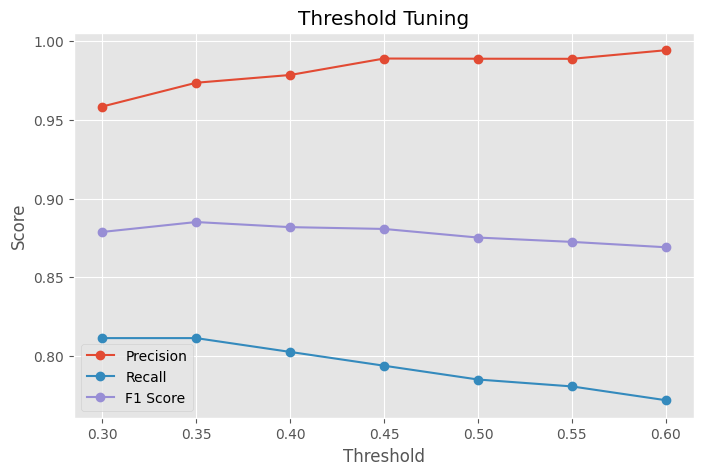

In [60]:
plt.figure(figsize=(8,5))

plt.plot(threshold_df["Threshold"],threshold_df["Precision"],marker="o",label="Precision")
plt.plot(threshold_df["Threshold"],threshold_df["Recall"],marker="o",label="Recall")
plt.plot(threshold_df["Threshold"],threshold_df["F1 Score"],marker="o",label="F1 Score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()

plt.show()

### Observation

• The default threshold (0.50) was not optimal for fraud detection.

• Threshold **0.35** achieved the best balance between Precision, Recall, and F1-score.

• Therefore, **0.35** was selected as the final classification threshold.

**Final Prediction (Threshold = 0.35)**

In [61]:
threshold = 0.35

y_pred_final = (y_prob >= threshold).astype(int)

**Final Confusion Matrix (Threshold = 0.35)**

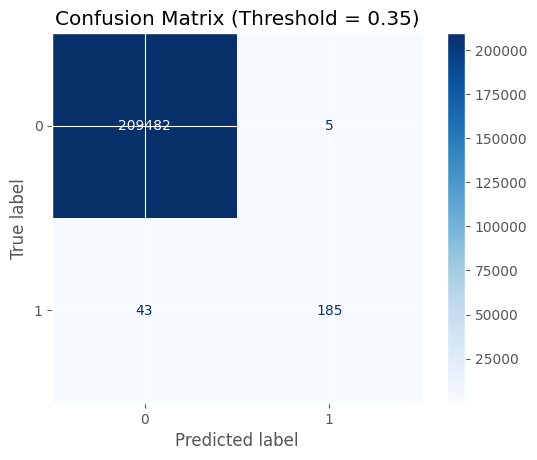

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_final)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Confusion Matrix (Threshold = 0.35)")
plt.show()

**Observation**

• Only 43 fraudulent transactions were missed (False Negatives).

• The model correctly detected 185 fraudulent transactions.

• The selected threshold significantly improved fraud detection while keeping false positives very low.

**Final Classification Report**

In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    209487
           1       0.97      0.81      0.89       228

    accuracy                           1.00    209715
   macro avg       0.99      0.91      0.94    209715
weighted avg       1.00      1.00      1.00    209715



**Final Metrics**

In [64]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

print("Accuracy :",accuracy_score(y_test,y_pred_final))
print("Precision:",precision_score(y_test,y_pred_final))
print("Recall   :",recall_score(y_test,y_pred_final))
print("F1 Score :",f1_score(y_test,y_pred_final))
print("ROC AUC  :",roc_auc_score(y_test,y_prob))

Accuracy : 0.9997711179457835
Precision: 0.9736842105263158
Recall   : 0.8114035087719298
F1 Score : 0.8851674641148325
ROC AUC  : 0.9956252362182337


## Threshold Optimization

The default decision threshold (0.50) was evaluated against multiple thresholds.

A threshold of **0.35** produced the highest F1 Score while improving Recall with only a small reduction in Precision.

Therefore, **0.35** was selected as the optimal decision threshold for the final fraud detection model.

##**FEATURE IMPORTANCE**

In [65]:
importance = pd.DataFrame({"Feature":xgb.feature_names_in_,"Importance":xgb.feature_importances_})
importance = importance.sort_values("Importance",ascending=False)
importance

,Feature,Importance
3,newbalanceOrig,0.174677
9,type_TRANSFER,0.164496
2,oldbalanceOrg,0.146641
5,newbalanceDest,0.134943
0,step,0.125227
8,type_PAYMENT,0.099716
1,amount,0.067123
6,type_CASH_OUT,0.055063
4,oldbalanceDest,0.032114
7,type_DEBIT,0.000000


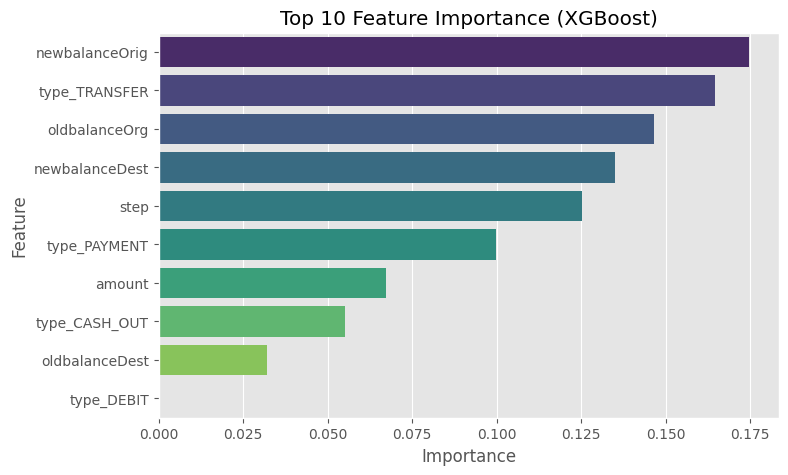

In [66]:
plt.figure(figsize=(8,5))
sns.barplot(data=importance.head(10),x="Importance",y="Feature",palette="viridis")
plt.title("Top 10 Feature Importance (XGBoost)")
plt.show()

**Feature Importance**

• Shows which features are most important for model predictions.

• Higher importance means the feature contributes more to the model.

• It provides global model interpretation.

• Unlike SHAP, it does not explain the direction of each prediction.

###***SHAP Explanability***

**SHAP (SHapley Additive exPlanations)**

SHAP explains how each feature contributes to individual predictions, making the XGBoost model transparent and interpretable.

It explains why the model made a particular prediction by showing the contribution of each feature.

In [67]:
import shap
explainer = shap.TreeExplainer(xgb)

In [68]:
shap_values = explainer.shap_values(X_test)

**SHAP Summary Plot**

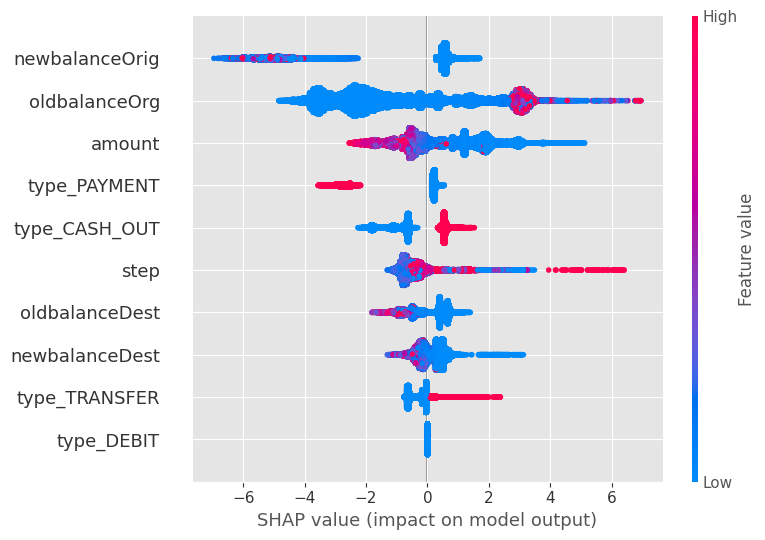

In [69]:
shap.summary_plot(shap_values, X_test)

### Observation

• Balance-related features have the greatest influence on model predictions.

• Transaction type also plays a significant role in identifying fraud.

• Both high and low feature values affect predictions differently depending on the transaction.

**SHAP Waterfall Plot Explanation**

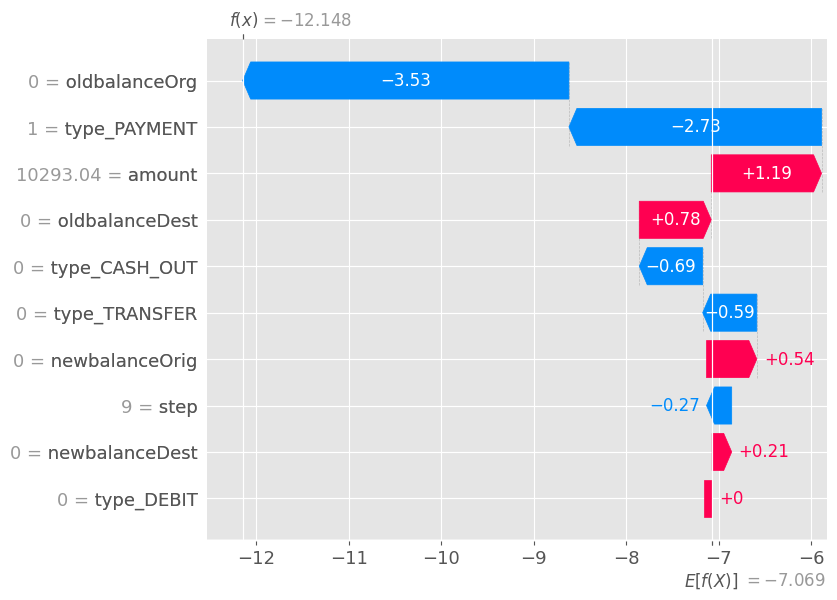

In [70]:
sample = 0

shap.plots.waterfall(shap.Explanation(values=shap_values[sample],base_values=explainer.expected_value,data=X_test.iloc[sample],feature_names=X_test.columns))

### Observation

• Blue bars decrease the fraud prediction.

• Red bars increase the fraud prediction.

• The final prediction is obtained by combining the contribution of all features.

##**Final Model Comparison Table**

In [71]:
comparison = pd.DataFrame({
    "Stage":["Baseline XGBoost","SMOTE","Tuned XGBoost","Final (Threshold=0.35)"],
    "Precision":[0.9519,0.3277,0.9890,0.9737],
    "Recall":[0.7807,0.9342,0.7985,0.8114],
    "F1 Score":[0.8578,0.4852,0.8835,0.8852],
    "ROC AUC":[0.9836,0.9921,0.9956,0.9956],
    "Decision":["Baseline","Rejected","Selected","Final"]
})

comparison

,Stage,Precision,Recall,F1 Score,ROC AUC,Decision
0,Baseline XGBoost,0.9519,0.7807,0.8578,0.9836,Baseline
1,SMOTE,0.3277,0.9342,0.4852,0.9921,Rejected
2,Tuned XGBoost,0.9890,0.7985,0.8835,0.9956,Selected
3,Final (Threshold=0.35),0.9737,0.8114,0.8852,0.9956,Final


##**Business Recommendations**

• Monitor CASH_OUT and TRANSFER transactions more closely.

• Trigger OTP or manual verification for high-risk transactions.

• Continuously monitor abnormal sender and receiver balance changes.

• Use the optimized threshold (0.35) for better fraud detection.

• Retrain the model periodically using newly available fraud data.

##**Conclusion**

An XGBoost model was selected as the final model after comparing multiple machine learning algorithms.

Hyperparameter tuning improved overall performance, while threshold optimization increased Recall without significantly reducing Precision.

The final model achieved an excellent balance between fraud detection capability and false alarm control, making it suitable for real-time fraud detection systems.

The final XGBoost model achieved strong Precision, Recall, F1 Score, and ROC-AUC while maintaining good generalization performance with no significant overfitting.

SHAP Explainability was used to improve model transparency by explaining both global feature importance and individual predictions.